In [24]:
import os
import sys

PROJECT_NAME = 'june-2026'

try:

    from google.colab import drive
    drive.mount('/content/drive')

    PROJECT_ROOT = f'D:/Data-Science/Practice/PnT/{PROJECT_NAME}'

    print("Running in Google Colab.")

except:

    PROJECT_ROOT = rf'D:/Data-Science/Practice/PnT/{PROJECT_NAME}'

    print("Running in local environment.")

# Move to project root
os.chdir(PROJECT_ROOT)

print("Current working directory:", os.getcwd())

# Add project root to Python path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

Running in local environment.
Current working directory: D:\Data-Science\Practice\PnT\june-2026


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

In [26]:
df = sns.load_dataset("titanic")
df.shape

(891, 15)

In [27]:
df["age"] = df["age"].fillna(df["age"].median())
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [28]:
# Sampling

population_mean = df["age"].mean()

sample = df["age"].sample(n=30, random_state=42)
sample_mean = sample.mean()

print(f"Population mean: {population_mean:.2f}")
print(f"Sample mean: {sample_mean:.2f}")

Population mean: 29.36
Sample mean: 26.00


<Axes: xlabel='age', ylabel='Count'>

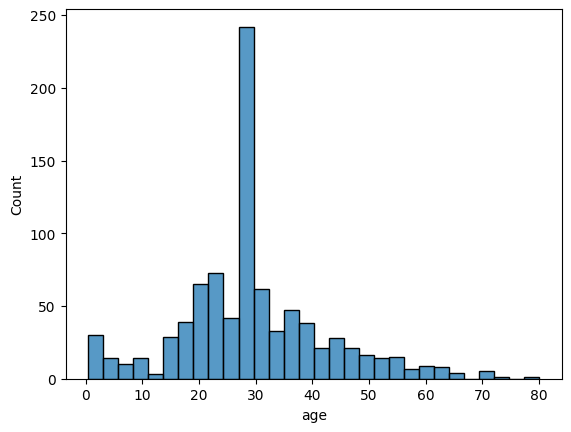

In [29]:
sns.histplot(df["age"], bins = 30)

In [30]:
# CLI

sample_age = []

for i in range(1000):
    sample = df["age"].sample(n=30, replace=True)
    sample_age.append(sample.mean())

sample_age = np.array(sample_age)
mean_of_sample_mean = sample_age.mean()


print(f"Population mean: {population_mean:.2f}")
print(f"Sample mean: {mean_of_sample_mean:.2f}")

Population mean: 29.36
Sample mean: 29.48


<Axes: ylabel='Count'>

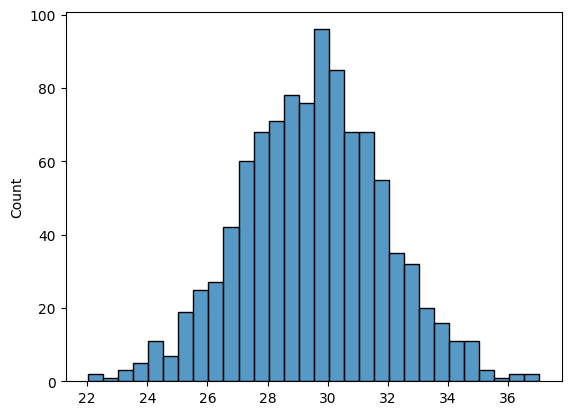

In [31]:
sns.histplot(sample_age, bins=30)

In [32]:
# Covariance

x = df["age"]
y = df["fare"]

cov_value = x.cov(y)
print(f"Covariance: {cov_value:.2f}")

Covariance: 62.56


In [44]:
# Hypothesis testing

group1 = df[df["sex"] == "male"]["age"]
group2 = df[df["sex"] == "female"]["age"]

t_stat, p_value = stats.ttest_ind(group1, group2)

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.2f}")

alpha = .05

if p_value < alpha:
    print("Reject the H0")
else:
    print("Fail to reject H0")

print("----------")
print(f"Male mean age: {group1.mean():.2f}")
print(f"Female mean age: {group2.mean():.2f}")
print(f"Difference: {group1.mean()-group2.mean():.2f}")
print(f"t-statistic: {t_stat:.2f}")
print(f"p-value: {p_value:.2f}")

T-statistic: 2.43
P-value: 0.02
Reject the H0
----------
Male mean age: 30.14
Female mean age: 27.93
Difference: 2.21
t-statistic: 2.43
p-value: 0.02


In [34]:
# Confidence Interval

#SE = STD/SQRT(N)

#CI = mean +/- Z*SE
age_mean = df["age"].mean()
age_std = df["age"].std()
n = len(df)

age_SE = age_std/np.sqrt(n)

lower95 = age_mean - (1.96 * age_SE)
upper95 = age_mean + (1.96 * age_SE)

print(lower95, upper95)

28.506677049623192 30.216487933541785


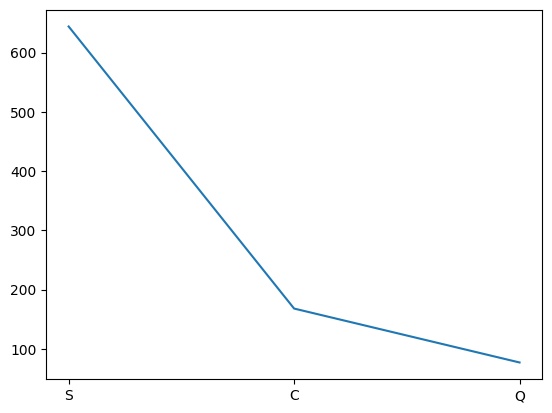

In [35]:
x = df["embarked"].value_counts()
plt.plot(x.index, x.values)
plt.show()

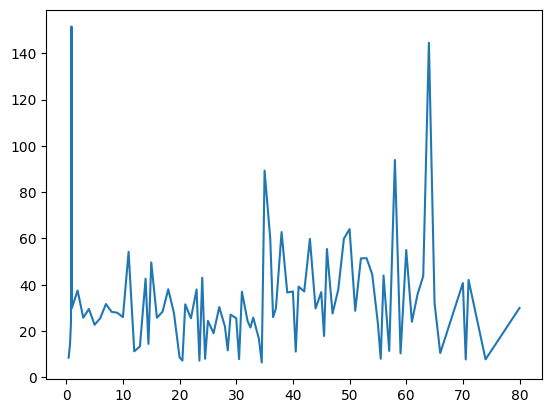

In [36]:
x = df.groupby(df["age"])["fare"].mean()
plt.plot(x.index, x.values)

<Axes: xlabel='sex', ylabel='count'>

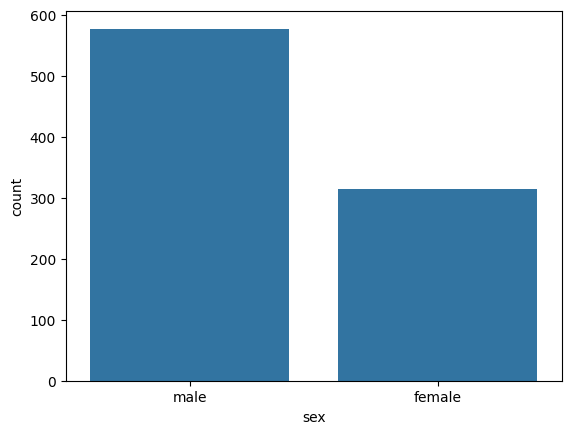

In [37]:
sns.countplot(x="sex", data=df)

<Axes: xlabel='age', ylabel='Count'>

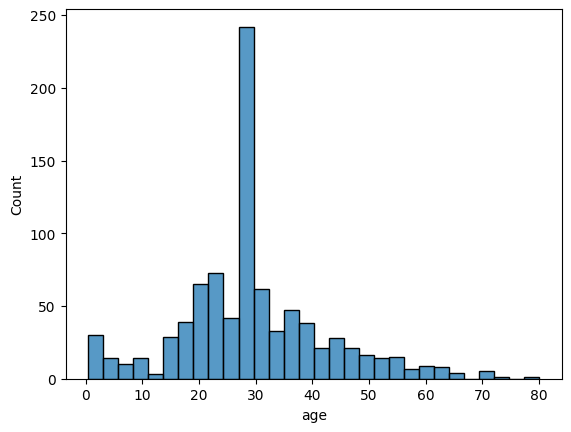

In [38]:
sns.histplot(x="age", data = df)

([<matplotlib.patches.Wedge at 0x2621e1ba5d0>,
 [Text(-0.4919454315896098, 0.9838646717603559, 'Male'),
  Text(0.49194551760179267, -0.9838646287531149, 'Female')])

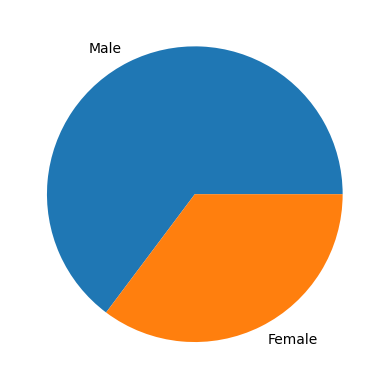

In [39]:
plt.pie(df["sex"].value_counts(), labels=["Male", "Female"])

<Axes: xlabel='age'>

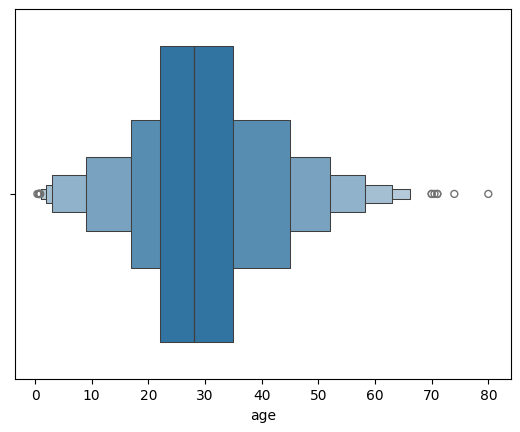

In [40]:
sns.boxenplot(x="age", data=df)

<Axes: xlabel='age'>

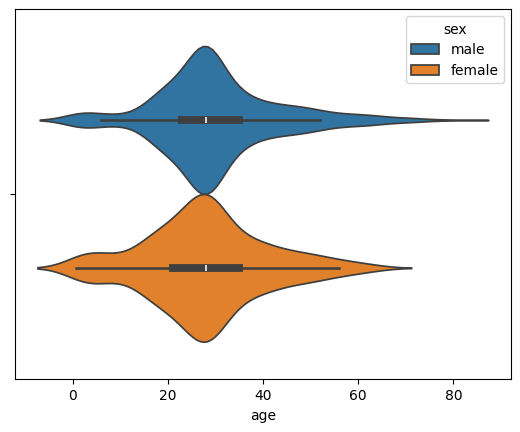

In [41]:
sns.violinplot(x="age", hue="sex", data=df)

<Axes: xlabel='fare', ylabel='age'>

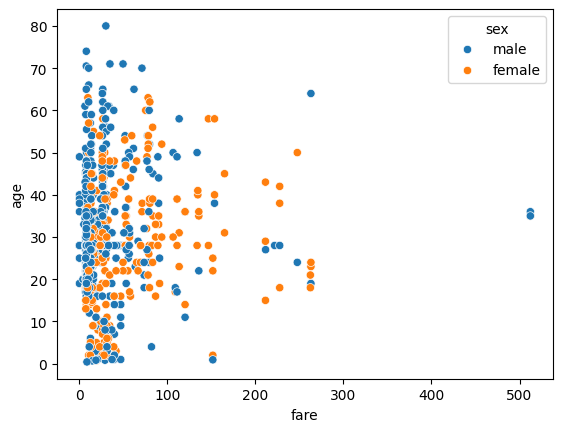

In [42]:
sns.scatterplot(x="fare", y="age", hue="sex", data=df)

<Axes: >

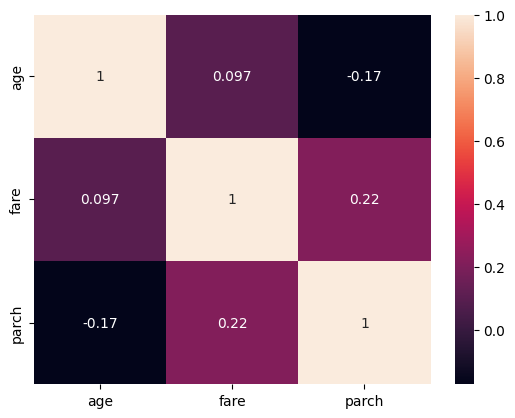

In [43]:
sns.heatmap(df[["age", "fare", "parch"]].corr(), annot=True)